**Programmer:** python_scripts (Abhijith Warrier)

**PYTHON SCRIPT TO _VISUALIZE DECISION BOUNDARIES USING SUPPORT VECTOR MACHINES (SVM)_. 🧠📉🧩**

This script demonstrates how to train an **SVM classifier** on a 2D dataset and visualize its **decision boundaries**, **margins**, and **support vectors**.

Decision boundary plots help you understand how SVM separates classes and how kernels influence the classification surface.

---

### 📦 Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

---

### 🧩 Load Dataset (2D for Visualization)

We’ll use the Iris dataset but only two features to keep it 2D.

In [2]:
iris = datasets.load_iris()
X = iris.data[:, :2]   # only sepal length & sepal width
y = iris.target

# Use only 2 classes for a clean boundary plot
mask = y != 2
X = X[mask]
y = y[mask]

---

### ✂️ Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

---

### 🤖 Train SVM Classifier

We’ll start with a linear kernel for simple visualization.

In [4]:
model = SVC(kernel="linear")
model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


---

### 📊 Visualize the Decision Boundary

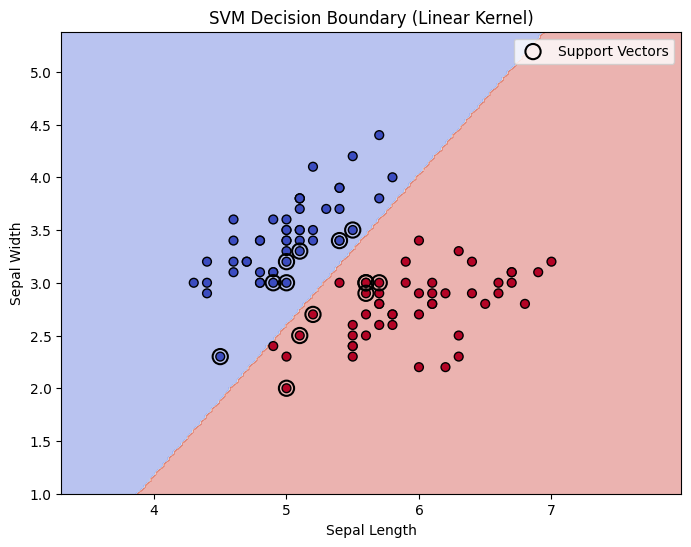

In [6]:
# Create a meshgrid
h = 0.02
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

# Predict on grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, cmap="coolwarm", alpha=0.4)

# Plot training points
plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", s=40, edgecolor="k")

# Highlight support vectors
sv = model.support_vectors_
plt.scatter(sv[:,0], sv[:,1], s=120, facecolors='none', edgecolors='k', linewidths=1.5, label="Support Vectors")

plt.title("SVM Decision Boundary (Linear Kernel)")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.savefig("/Users/abhijith/Downloads/AIwP-VDB-Output.png")
plt.legend()

---

### 🎯 Notes
- Support vectors lie closest to the margin and control the decision boundary.
- Changing the kernel (e.g., 'rbf', 'poly') will drastically change the shape of the boundary.
- Pairplot-style visualizations are only for 2D — hence the feature selection.


---